# CIFAR-10 CNN Architecture Search with KerasTuner

trying to find a decent CNN architecture for CIFAR-10 using RandomSearch instead of tuning it by hand. based on the same idea from [this notebook](https://colab.research.google.com/github/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb) (the fashion mnist hyperparameter tuning example) but adapted for a CNN since CIFAR-10 is RGB and more complex.

In [1]:
from google.colab import drive
import os

drive.mount("/content/drive")

PROJECT = "/content/drive/MyDrive/Search_with_KerasTuner"
DATA_DIR = "/content/datasets"

os.makedirs(PROJECT, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

Mounted at /content/drive


In [2]:
MODEL_DIR = os.path.join(PROJECT, "models")
OUTPUT_DIR = os.path.join(PROJECT, "outputs")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

## imports

In [3]:
# keras-tuner is not pre-installed on Colab
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.8 MB/s eta 0:00:00


In [4]:
import numpy as np
import tensorflow as tf
import keras_tuner as kt
import json
import matplotlib.pyplot as plt

# fixing seed so results are at least somewhat reproducible between runs
tf.random.set_seed(42)
np.random.seed(42)

print(tf.__version__)
print(kt.__version__)

# check if we actually got a GPU this time
print(tf.config.list_physical_devices("GPU"))

2.20.0
1.4.8
[]


## loading the data

CIFAR-10, 10 classes, 32x32 RGB images. loading it straight from keras.datasets

In [5]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# labels come back as (N, 1), flattening to (N,) because it's annoying otherwise
y_train_full = y_train_full.squeeze()
y_test = y_test.squeeze()

# scaling pixels to 0-1
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# holding out 5000 images for validation, rest for training
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1789s 10us/step
(45000, 32, 32, 3) (45000,)
(5000, 32, 32, 3) (5000,)
(10000, 32, 32, 3) (10000,)


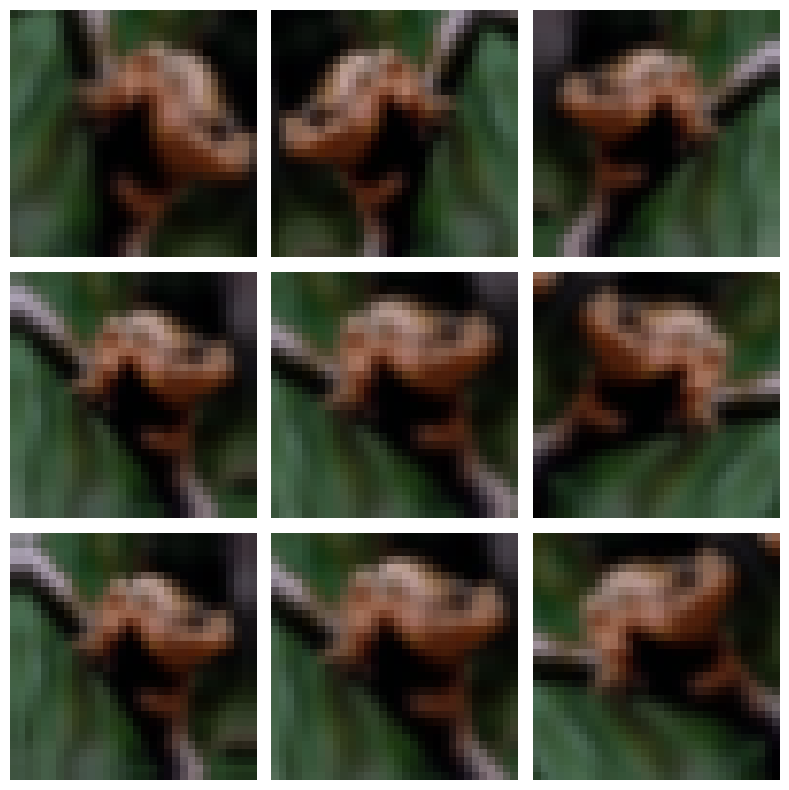

In [6]:
# adding some light augmentation, mainly flips and small rotations/zoom
# doing it as a Sequential of preprocessing layers so it only runs during
# training (keras handles that automatically for these layers)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# quick check on one image to make sure it's actually doing something
plt.figure(figsize=(8, 8))
sample_img = X_train[0:1]
for i in range(9):
    augmented = data_augmentation(sample_img, training=True)
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented[0])
    plt.axis("off")
plt.tight_layout()
plt.show()

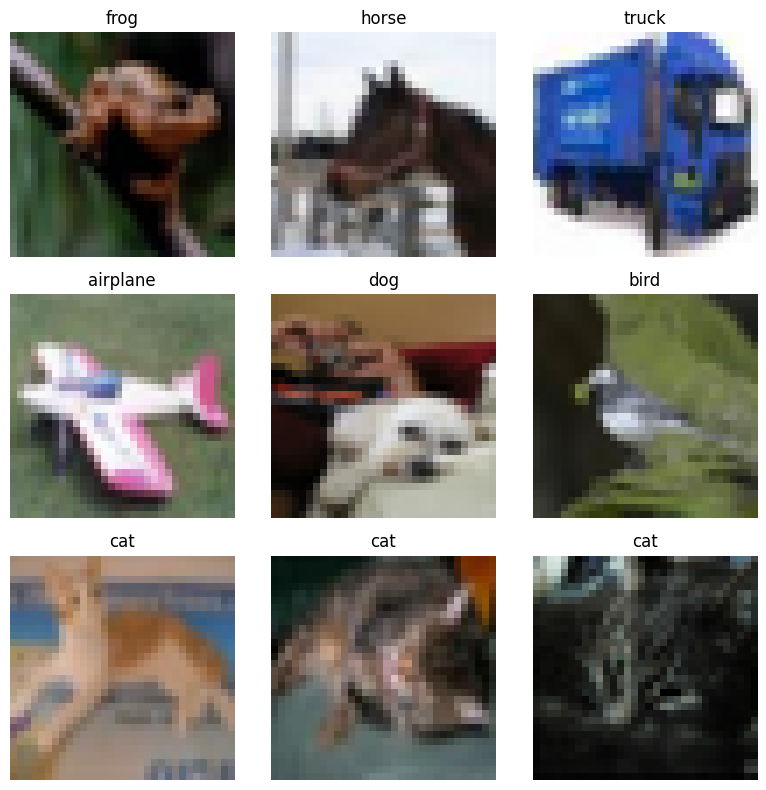

In [7]:
# quick sanity check, just want to see the images look right after normalizing
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## build_model function

this is the main part. instead of just tuning n_hidden/n_neurons like the fashion mnist example, tuning the actual CNN structure:

- how many conv blocks (1-4)
- kernel size 3x3 or 5x5
- batch norm on/off
- dropout rate
- how many dense layers after the conv part + how many units
- optimizer + learning rate

for the filters I'm not letting each block pick its own filter count separately, that blows up the search space way too much. just using a fixed schedule (32, 64, 128, 256) and picking how many blocks to use from that list.

In [8]:
FILTER_SCHEDULE = [32, 64, 128, 256]


def build_model(hp):
    # architecture params
    n_conv_blocks = hp.Int("n_conv_blocks", min_value=1, max_value=4, default=2)
    kernel_size = hp.Choice("kernel_size", values=[3, 5], default=3)
    use_batch_norm = hp.Boolean("use_batch_norm", default=True)
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1, default=0.2)

    n_dense_layers = hp.Int("n_dense_layers", min_value=0, max_value=2, default=1)
    dense_units = hp.Int("dense_units", min_value=64, max_value=256, step=64, default=128)

    # optimizer params
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer_name = hp.Choice("optimizer", values=["sgd", "adam"])

    if optimizer_name == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(32, 32, 3)))
    model.add(data_augmentation)  # only active during training

    for i in range(n_conv_blocks):
        filters = FILTER_SCHEDULE[i]
        model.add(tf.keras.layers.Conv2D(filters, kernel_size, padding="same"))
        if use_batch_norm:
            model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation("relu"))
        model.add(tf.keras.layers.MaxPooling2D(pool_size=2))

    model.add(tf.keras.layers.Flatten())

    for _ in range(n_dense_layers):
        model.add(tf.keras.layers.Dense(dense_units, activation="relu"))
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(10, activation="softmax"))

    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=optimizer,
                  metrics=["accuracy"])
    return model

## setting up the tuner

saving the tuner's own files (trial logs etc) inside PROJECT/outputs too so everything stays in one place on Drive. started with max_trials=20, might bump it up later if I have time left on the GPU.

In [11]:
random_search_tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=8,
    overwrite=True,
    directory=os.path.join(OUTPUT_DIR, "kerastuner_logs"),
    project_name="cifar10_cnn_search",
    seed=42,
)

random_search_tuner.search_space_summary()

Search space summary
Default search space size: 8
n_conv_blocks (Int)
{'default': 2, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
kernel_size (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5], 'ordered': True}
use_batch_norm (Boolean)
{'default': True, 'conditions': []}
dropout_rate (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
n_dense_layers (Int)
{'default': 1, 'conditions': [], 'min_value': 0, 'max_value': 2, 'step': 1, 'sampling': 'linear'}
dense_units (Int)
{'default': 128, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
optimizer (Choice)
{'default': 'sgd', 'conditions': [], 'values': ['sgd', 'adam'], 'ordered': False}


In [12]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

random_search_tuner.search(
    X_train, y_train,
    epochs=10,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping_cb],
)

Trial 8 Complete [00h 13m 18s]
val_accuracy: 0.4869999885559082

Best val_accuracy So Far: 0.6970000267028809
Total elapsed time: 02h 39m 38s


## checking the results

In [13]:
top3_models = random_search_tuner.get_best_models(num_models=3)
best_model = top3_models[0]

top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'SGD', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'SGD', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


{'n_conv_blocks': 4,
 'kernel_size': 3,
 'use_batch_norm': False,
 'dropout_rate': 0.30000000000000004,
 'n_dense_layers': 2,
 'dense_units': 64,
 'learning_rate': 0.0003491260272208854,
 'optimizer': 'adam'}

In [14]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 4 summary
Hyperparameters:
n_conv_blocks: 4
kernel_size: 3
use_batch_norm: False
dropout_rate: 0.30000000000000004
n_dense_layers: 2
dense_units: 64
learning_rate: 0.0003491260272208854
optimizer: adam
Score: 0.6970000267028809


In [15]:
print("best val_accuracy from the search:", best_trial.metrics.get_last_value("val_accuracy"))

best val_accuracy from the search: 0.6970000267028809


In [16]:
def print_best_architecture(hp_values):
    n_blocks = hp_values["n_conv_blocks"]
    print("Best Architecture")
    print("------------------")
    for i in range(n_blocks):
        print(f"Conv Block {i + 1}: {FILTER_SCHEDULE[i]} filters")
    print(f"Kernel Size: {hp_values['kernel_size']}x{hp_values['kernel_size']}")
    print(f"Batch Normalization: {hp_values['use_batch_norm']}")
    print(f"Dropout: {hp_values['dropout_rate']:.2f}")
    print(f"Dense Layers: {hp_values['n_dense_layers']}")
    print(f"Dense Units: {hp_values['dense_units']}")
    print(f"Optimizer: {hp_values['optimizer']}")
    print(f"Learning Rate: {hp_values['learning_rate']:.5f}")


print_best_architecture(top3_params[0].values)

# saving the best hyperparameters to Drive so I don't have to redo the search
# just to remember what won
with open(os.path.join(OUTPUT_DIR, "best_hyperparameters.json"), "w") as f:
    json.dump(top3_params[0].values, f, indent=2)

Best Architecture
------------------
Conv Block 1: 32 filters
Conv Block 2: 64 filters
Conv Block 3: 128 filters
Conv Block 4: 256 filters
Kernel Size: 3x3
Batch Normalization: False
Dropout: 0.30
Dense Layers: 2
Dense Units: 64
Optimizer: adam
Learning Rate: 0.00035


## retraining on the full training set

now taking the winning hyperparameters and retraining from scratch on X_train_full (train + the validation chunk together), then testing on X_test which the model hasn't touched at all yet.

In [17]:
best_hp = top3_params[0]
final_model = random_search_tuner.hypermodel.build(best_hp)

history = final_model.fit(
    X_train_full, y_train_full,
    epochs=20,
    validation_split=0.1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 189s 132ms/step - accuracy: 0.2947 - loss: 1.8955 - val_accuracy: 0.4208 - val_loss: 1.5638
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 201s 132ms/step - accuracy: 0.4243 - loss: 1.5708 - val_accuracy: 0.4698 - val_loss: 1.4706
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 199s 129ms/step - accuracy: 0.4884 - loss: 1.4252 - val_accuracy: 0.5592 - val_loss: 1.2505
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 203s 130ms/step - accuracy: 0.5307 - loss: 1.3216 - val_accuracy: 0.6008 - val_loss: 1.1244
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 130ms/step - accuracy: 0.5626 - loss: 1.2479 - val_accuracy: 0.6028 - val_loss: 1.1454
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 185s 132ms/step - accuracy: 0.5924 - loss: 1.1773 - val_accuracy: 0.6270 - val_loss: 1.0954
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 185s 131ms/step - accuracy: 0.6088 - loss: 1.1265 - val_accuracy: 0.6518 - val_loss: 1.0035
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 201s 131ms/step - ac

In [19]:
# saving the trained model to Drive
final_model.save(os.path.join(MODEL_DIR, "cifar10_best_model.keras"))

In [21]:
test_loss, test_accuracy = final_model.evaluate(X_test, y_test)
print(f"test loss: {test_loss:.4f}")
print(f"test accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.7079 - loss: 0.8565
test loss: 0.8565
test accuracy: 0.7079


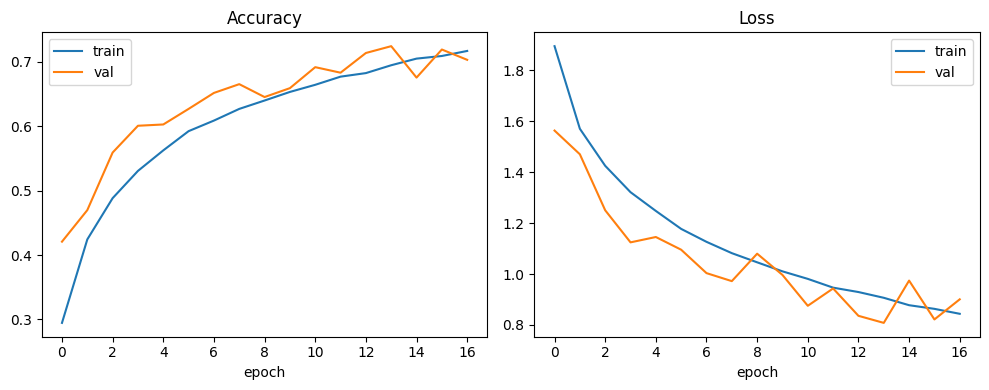

In [22]:
# plotting training curves, saving the figure to Drive too
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("epoch")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"))
plt.show()

## notes to self

- max_trials=20 is just a starting point, if I have more Colab time left I should push it to 30-40
- could try kt.Hyperband instead of RandomSearch, it kills off bad trials early so it's faster
- data augmentation (random flip/rotation) would probably help generalization, haven't added it yet